# NHL Salary Prediction — EDA

## Часть 1. Первичный анализ сырых данных

Цель этого раздела - понять структуру данных, распределение целевой переменной
и характер пропусков. На основе наблюдений принимаются решения по очистке
и трансформациям в `src/preprocessing.py`.

## 0. Источники данных

Данные собраны из трёх источников:

| Источник | Что содержит | Метод сбора |
|---|---|---|
| NHL Stats API (`api.nhle.com`) | Игровая статистика, биография | `requests` |
| NHL Web API (`api-web.nhle.com`) | Рост, вес, драфт | `requests` |
| Spotrac (`spotrac.com`) | Cap hit — зарплата против потолка | `Selenium` |

**Почему эти источники:**
- NHL Stats API - официальный источник статистики, бесплатный, полный охват сезонов
- Spotrac - наиболее полная база контрактов NHL, включает точный cap hit по каждому сезону
- Данные объединены по нормализованному имени игрока (`name_key`)

**Сезоны:** 2021-22 → 2025-26 (только регулярный сезон)  
**Единица наблюдения:** один игрок в одном сезоне

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

root = Path("..") 

sk = pd.read_csv(root / "data" / "raw" / "nhl_skaters_raw.csv")
go = pd.read_csv(root / "data" / "raw" / "nhl_goalies_raw.csv")

print("Скейтеры:", sk.shape)
print("Вратари:  ", go.shape)
print("\nСезоны скейтеры:", sorted(sk["season_year"].unique()))
print("Сезоны вратари: ", sorted(go["season_year"].unique()))

Скейтеры: (4748, 90)
Вратари:   (525, 46)

Сезоны скейтеры: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Сезоны вратари:  [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


### Результат

- Скейтеры: **4748 строк × 90 колонок** - 5 сезонов, около 900-1000 игроков в среднем за сезон
- Вратари: **525 строк × 46 колонок** - вратарей значительно меньше, это ожидаемо 
- Единица наблюдения: один игрок в одном сезоне, то есть один игрок может встречаться до 5 раз

In [7]:
print("Колонки скейтеров по группам:")
print()

groups = {
    "Идентификация": ["playerId", "skaterFullName", "lastName", "positionCode",
                      "shootsCatches", "teamAbbrevs", "season", "season_year"],
    "Базовая статистика": ["gamesPlayed", "goals", "assists", "points", "pointsPerGame",
                           "plusMinus", "penaltyMinutes", "shots", "shootingPct",
                           "timeOnIcePerGame"],
    "Realtime": ["hits", "blockedShots", "giveaways", "takeaways", "totalShotAttempts"],
    "Большинство": [c for c in sk.columns if c.startswith("pp")],
    "Вбрасывания": [c for c in sk.columns if "aceoff" in c],
    "Биография": ["heightInInches", "weightInPounds", "birthCountry",
                  "draftYear", "draftRound", "draftOverall"],
    "Таргет (Spotrac)": ["cap_hit"],
}

for group, cols in groups.items():
    existing = [c for c in cols if c in sk.columns]
    print(f"{group} ({len(existing)} колонок): {existing}")
    print()

Колонки скейтеров по группам:

Идентификация (8 колонок): ['playerId', 'skaterFullName', 'lastName', 'positionCode', 'shootsCatches', 'teamAbbrevs', 'season', 'season_year']

Базовая статистика (10 колонок): ['gamesPlayed', 'goals', 'assists', 'points', 'pointsPerGame', 'plusMinus', 'penaltyMinutes', 'shots', 'shootingPct', 'timeOnIcePerGame']

Realtime (5 колонок): ['hits', 'blockedShots', 'giveaways', 'takeaways', 'totalShotAttempts']

Большинство (20 колонок): ['ppGoals', 'ppPoints', 'ppFaceoffPct', 'ppFaceoffs', 'ppAssists', 'ppGoalsForPer60', 'ppGoalsPer60', 'ppIndividualSatFor', 'ppIndividualSatForPer60', 'ppPointsPer60', 'ppPrimaryAssists', 'ppPrimaryAssistsPer60', 'ppSecondaryAssists', 'ppSecondaryAssistsPer60', 'ppShootingPct', 'ppShots', 'ppShotsPer60', 'ppTimeOnIce', 'ppTimeOnIcePctPerGame', 'ppTimeOnIcePerGame']

Вбрасывания (14 колонок): ['faceoffWinPct', 'defensiveZoneFaceoffPct', 'defensiveZoneFaceoffs', 'evFaceoffPct', 'evFaceoffs', 'neutralZoneFaceoffPct', 'neutralZone

### Структура колонок скейтеров (90 всего)

| Группа | Колонок | Примечание |
|---|---|---|
| Идентификация | 8 | ID, имя, позиция, команда, сезон |
| Базовая статистика | 10 | Голы, передачи, очки, время на льду |
| Realtime | 5 | Хиты, блоки, Corsi |
| Большинство | 20 | Детальная статистика игры в большинстве |
| Вбрасывания | 14 | По зонам и составам |
| Биография | 6 | Рост, вес, драфт |
| Прочие | 26 | Меньшинство, пустые ворота, промахи и др. |
| Таргет | 1 | `cap_hit` - зарплата против потолка |

Группы "Большинство" и "Вбрасывания" содержат много взаимокоррелирующих колонок,
на этапе моделирования потребуется отбор признаков или уменьшение размерности.

In [9]:
print("Типы данных скейтеры:")
print(sk.dtypes.value_counts())
print()

object_cols = sk.select_dtypes(include="str").columns.tolist()
print("Строковые колонки:", object_cols)
print()

print("Типы данных вратари:")
print(go.dtypes.value_counts())
print()

object_cols_go = go.select_dtypes(include="str").columns.tolist()
print("Строковые колонки:", object_cols_go)

Типы данных скейтеры:
int64      45
float64    34
str        11
Name: count, dtype: int64

Строковые колонки: ['lastName', 'positionCode', 'shootsCatches', 'skaterFullName', 'teamAbbrevs', 'name_key', 'birthCity', 'birthCountry', 'player_name_cw', 'team_cw', 'position_cw']

Типы данных вратари:
int64      26
str        10
float64    10
Name: count, dtype: int64

Строковые колонки: ['goalieFullName', 'lastName', 'shootsCatches', 'teamAbbrevs', 'name_key', 'birthCity', 'birthCountry', 'player_name_cw', 'team_cw', 'position_cw']


### Типы данных

**Скейтеры:** 45 int64, 34 float64, 11 строковых  
**Вратари:** 26 int64, 10 float64, 10 строковых

Строковые колонки делятся на две группы:

- **Нужны для модели после кодирования:** `positionCode`, `shootsCatches`, `birthCountry`
- **Служебные / leakage — будут удалены в preprocessing:** `name_key`, `player_name_cw`, `team_cw`, `position_cw`
- **Не используются в модели:** `skaterFullName`, `lastName`, `birthCity`, `teamAbbrevs` (заменится флагом `is_multi_team`)

In [10]:
print("Дубликаты скейтеры:")
full_dupes_sk = sk.duplicated().sum()
player_season_dupes_sk = sk.duplicated(subset=["playerId", "season_year"]).sum()
print(f"  Полных дублей: {full_dupes_sk}")
print(f"  Дублей по (playerId, season_year): {player_season_dupes_sk}")

print()
print("Дубликаты вратари:")
full_dupes_go = go.duplicated().sum()
player_season_dupes_go = go.duplicated(subset=["playerId", "season_year"]).sum()
print(f"  Полных дублей: {full_dupes_go}")
print(f"  Дублей по (playerId, season_year): {player_season_dupes_go}")

print()
print("Уникальных игроков скейтеры:", sk["playerId"].nunique())
print("Уникальных игроков вратари: ", go["playerId"].nunique())
print()
print("Среднее сезонов на игрока скейтеры:", round(len(sk) / sk["playerId"].nunique(), 2))
print("Среднее сезонов на игрока вратари: ", round(len(go) / go["playerId"].nunique(), 2))

Дубликаты скейтеры:
  Полных дублей: 0
  Дублей по (playerId, season_year): 9

Дубликаты вратари:
  Полных дублей: 0
  Дублей по (playerId, season_year): 0

Уникальных игроков скейтеры: 1481
Уникальных игроков вратари:  174

Среднее сезонов на игрока скейтеры: 3.21
Среднее сезонов на игрока вратари:  3.02


### Дубликаты

Полных дублей нет ни у скейтеров, ни у вратарей.

У скейтеров обнаружено **9 дублей по (playerId, season_year)** - это игроки,
которые за один сезон сменили команду и попали в датасет дважды. В preprocessing они будут схлопнуты в одну строку.

**Уникальных игроков:** 1481 скейтер, 174 вратаря  
**Среднее сезонов на игрока:** ~3.2 - большинство игроков присутствует в 3-4 сезонах из 5.

In [11]:
print("cap_hit скейтеры")
print(sk["cap_hit"].describe().round(0))
print(f"\nПропусков: {sk['cap_hit'].isna().sum()} ({sk['cap_hit'].isna().mean():.1%})")
print(f"Скошенность (skew): {sk['cap_hit'].skew():.2f}")

print()
print("cap_hit вратари")
print(go["cap_hit"].describe().round(0))
print(f"\nПропусков: {go['cap_hit'].isna().sum()} ({go['cap_hit'].isna().mean():.1%})")
print(f"Скошенность (skew): {go['cap_hit'].skew():.2f}")

cap_hit скейтеры
count        3128.0
mean      3593544.0
std       2868904.0
min        224000.0
25%        925000.0
50%       2900000.0
75%       5500000.0
max      17000000.0
Name: cap_hit, dtype: float64

Пропусков: 1620 (34.1%)
Скошенность (skew): 0.90

cap_hit вратари
count         319.0
mean      3346816.0
std       2511772.0
min        733333.0
25%       1000000.0
50%       2750000.0
75%       5000000.0
max      11500000.0
Name: cap_hit, dtype: float64

Пропусков: 206 (39.2%)
Скошенность (skew): 0.99


### Целевая переменная - cap_hit

|  | Скейтеры | Вратари |
|---|---|---|
| Записей с зарплатой | 3128 | 319 |
| Пропусков | 1620 (34.1%) | 206 (39.2%) |
| Минимум | 224 000 | 733 333 |
| Медиана | 2 900 000 | 2 750 000 |
| Максимум | 17 000 000 | 11 500 000 |
| Скошенность | 0.90 | 0.99 |

Распределение умеренно скошено вправо,
большинство игроков получают около медианы, но есть хвост из топ-игроков
с контрактами 10M+. Логарифмирование скорее оправдано: после него распределение
будет ближе к нормальному.

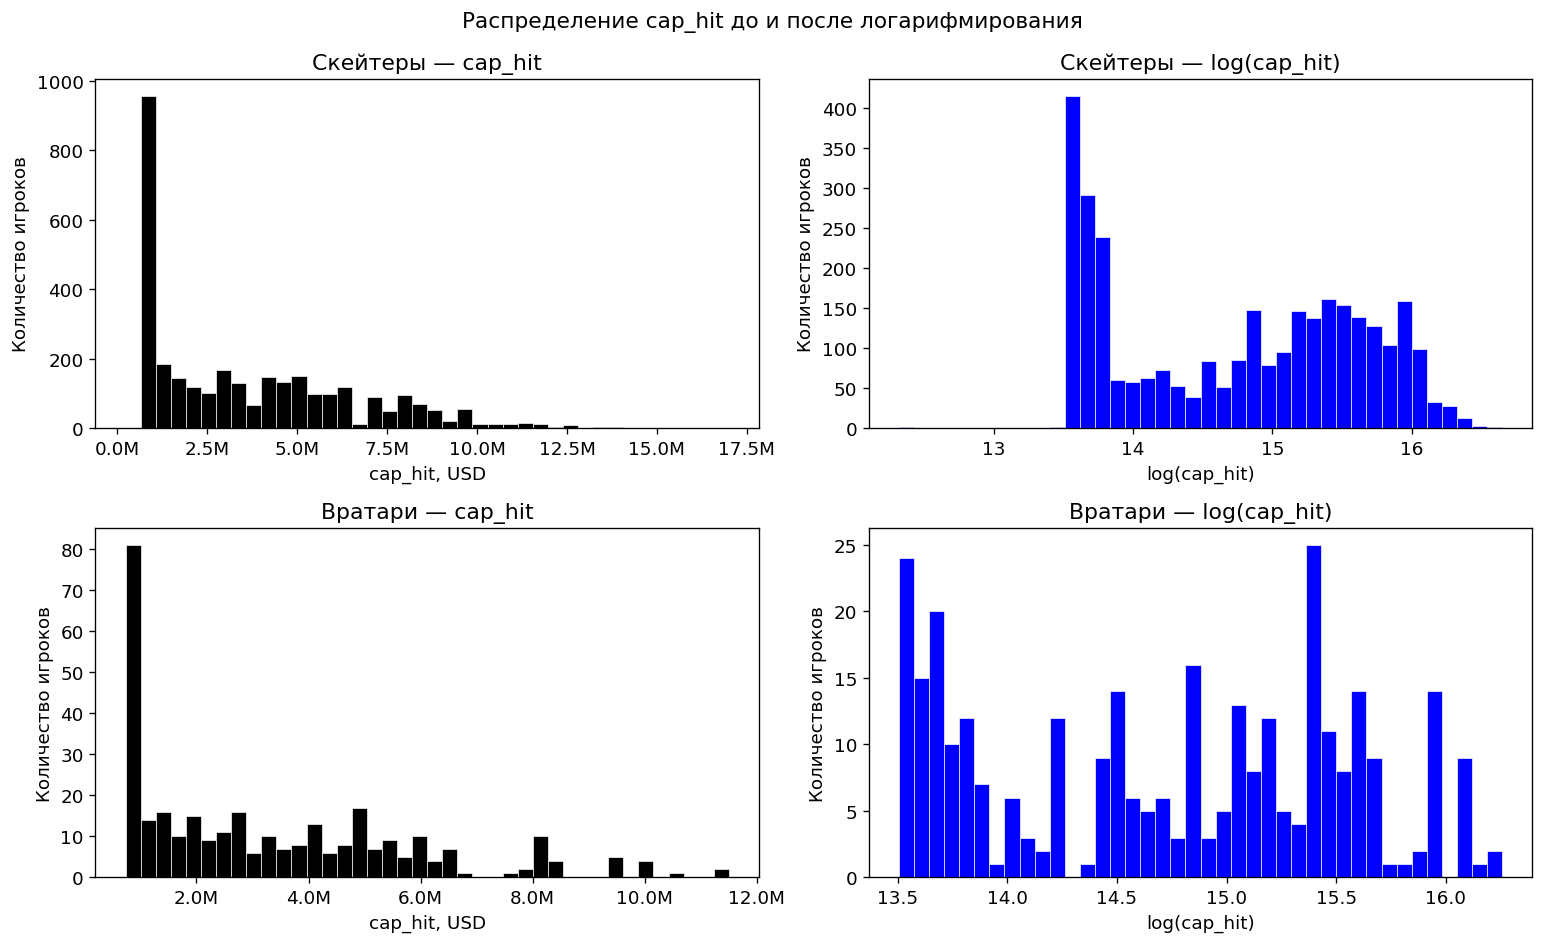

Скошенность cap_hit скейтеры: 0.90
Скошенность log(cap_hit) скейтеры: -0.01

Скошенность cap_hit вратари: 0.99
Скошенность log(cap_hit) вратари: -0.04


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for i, (df, label) in enumerate([(sk, "Скейтеры"), (go, "Вратари")]):
    data = df["cap_hit"].dropna()

    axes[i, 0].hist(data, bins=40, color="black", edgecolor="white", linewidth=0.4)
    axes[i, 0].set_title(f"{label} — cap_hit")
    axes[i, 0].set_xlabel("cap_hit, USD")
    axes[i, 0].set_ylabel("Количество игроков")
    axes[i, 0].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
    )

    axes[i, 1].hist(np.log1p(data), bins=40, color="blue", edgecolor="white", linewidth=0.4)
    axes[i, 1].set_title(f"{label} — log(cap_hit)")
    axes[i, 1].set_xlabel("log(cap_hit)")
    axes[i, 1].set_ylabel("Количество игроков")

plt.suptitle("Распределение cap_hit до и после логарифмирования", fontsize=13)
plt.tight_layout()
plt.savefig(root / "report/images/cap_hit_distribution.png", bbox_inches="tight")
plt.show()

print(f"Скошенность cap_hit скейтеры: {sk['cap_hit'].skew():.2f}")
print(f"Скошенность log(cap_hit) скейтеры: {np.log1p(sk['cap_hit'].dropna()).skew():.2f}")
print()
print(f"Скошенность cap_hit вратари: {go['cap_hit'].skew():.2f}")
print(f"Скошенность log(cap_hit) вратари: {np.log1p(go['cap_hit'].dropna()).skew():.2f}")

### Распределение cap_hit

После логарифмирования скошенность практически исчезает:

| | cap_hit skew | log(cap_hit) skew |
|---|---|---|
| Скейтеры | 0.90 | -0.01 |
| Вратари | 0.99 | -0.04 |

Скошенность 0.01–-0.04 после логарифма т.е. трансформация 
убирает асимметрию. **Вывод: в preprocessing и моделировании используем `log(cap_hit)`
как целевую переменную**

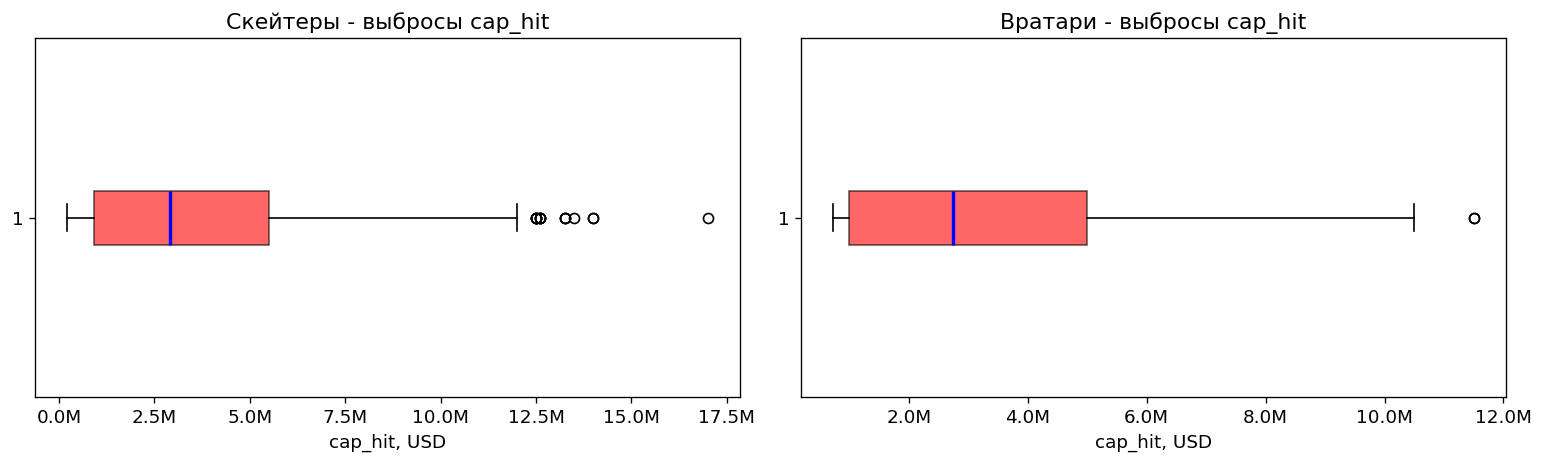

Топ-5 скейтеров по зарплате:
 skaterFullName  season_year    cap_hit  points
Kirill Kaprizov         2026 17000000.0      89
 Leon Draisaitl         2025 14000000.0     106
 Leon Draisaitl         2026 14000000.0      97
    Jack Eichel         2026 13500000.0      90
Auston Matthews         2024 13250000.0     107

Топ-5 вратарей по зарплате:
  goalieFullName  season_year    cap_hit  wins
 Igor Shesterkin         2025 11500000.0    27
 Igor Shesterkin         2026 11500000.0    25
     Carey Price         2022 10500000.0     1
Sergei Bobrovsky         2022 10000000.0    39
Sergei Bobrovsky         2023 10000000.0    24

Нижние 5 скейтеров по зарплате:
      skaterFullName  season_year  cap_hit  points
       Ville Heinola         2023 224000.0       1
         Matt Martin         2024 701963.0       8
     Hudson Fasching         2022 750000.0       0
Jaret Anderson-Dolan         2022 750000.0       0
          Mason Shaw         2022 750000.0       0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, (df, label) in enumerate([(sk, "Скейтеры"), (go, "Вратари")]):
    data = df["cap_hit"].dropna()
    axes[i].boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor="red", alpha=0.6),
                    medianprops=dict(color="blue", linewidth=2))
    axes[i].set_title(f"{label} - выбросы cap_hit")
    axes[i].set_xlabel("cap_hit, USD")
    axes[i].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
    )

plt.tight_layout()
plt.savefig(root / "report/images/cap_hit_boxplot.png", bbox_inches="tight")
plt.show()

print("Топ-5 скейтеров по зарплате:")
print(sk.nlargest(5, "cap_hit")[["skaterFullName", "season_year", "cap_hit", "points"]].to_string(index=False))
print()
print("Топ-5 вратарей по зарплате:")
print(go.nlargest(5, "cap_hit")[["goalieFullName", "season_year", "cap_hit", "wins"]].to_string(index=False))
print()
print("Нижние 5 скейтеров по зарплате:")
print(sk.nsmallest(5, "cap_hit")[["skaterFullName", "season_year", "cap_hit", "points"]].to_string(index=False))

### Выбросы cap_hit

На boxplot видны выбросы в верхней части - это суперзвёзды с контрактами 12M+.
У скейтеров 4 точки выше усов, у вратарей 1.

**Топ зарплат выглядят валидно** - это реальные топ-игроки лиги с соответствующей статистикой.
Carey Price в топе вратарей при 1 победе ь.к. он был травмирован весь сезон 2021-22,
но контракт продолжал считаться против потолка. Это реальная особенность NHL, а
не ошибка данных.

**Нижняя граница** - минимальный контракт NHL в эти сезоны составлял около 750K
(но Ville Heinola попал на 224K и это нетипично низкое значение, стоит проверить).

Выбросы в верхней части не удаляем т.к. топ-зарплаты являются частью задачи
предсказания. После логарифмирования их влияние на функцию потерь снижается естественным образом.

In [16]:
print("Проверка минимального значения cap_hit у скейтеров:")
print(sk[sk["cap_hit"] < 500000][["skaterFullName", "season_year", "cap_hit", "gamesPlayed", "teamAbbrevs"]])

Проверка минимального значения cap_hit у скейтеров:
     skaterFullName  season_year   cap_hit  gamesPlayed teamAbbrevs
1112  Ville Heinola         2023  224000.0           10         WPG


Spotrac мог подтянуть AHL-ставку вместо NHL cap hit. Это единственное такое значение в датасете,
удалять строку не будем, но в preprocessing можно поставить нижний порог
на уровне минимального контракта NHL и отфильтровать аномальные значения.

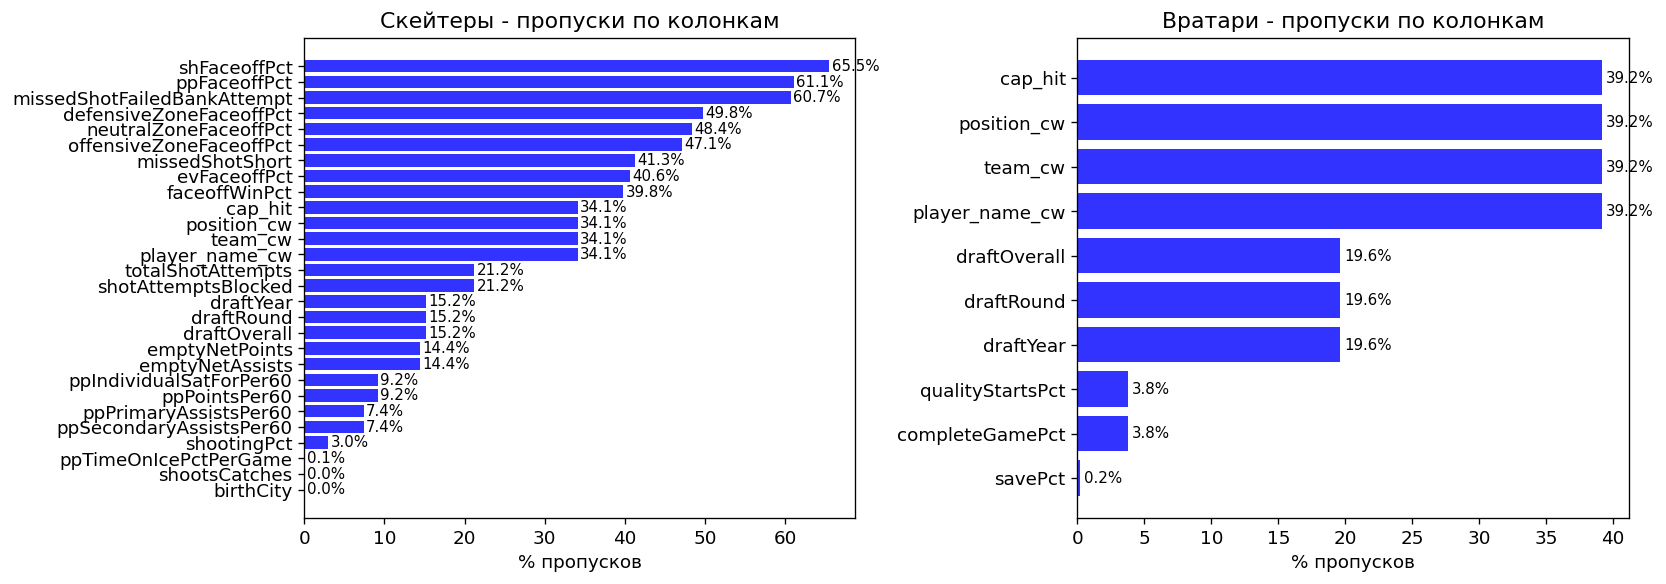

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (df, label, id_col) in enumerate([
    (sk, "Скейтеры", "skaterFullName"),
    (go, "Вратари", "goalieFullName")
]):
    missing = df.isnull().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    pct = (missing / len(df) * 100).round(1)

    axes[i].barh(missing.index[::-1], pct.values[::-1], color="blue", alpha=0.8)
    axes[i].set_title(f"{label} - пропуски по колонкам")
    axes[i].set_xlabel("% пропусков")
    for j, v in enumerate(pct.values[::-1]):
        axes[i].text(v + 0.3, j, f"{v}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(root / "report/images/missing_values.png", bbox_inches="tight")
plt.show()

### Анализ пропусков

**Скейтеры**: три группы пропусков с разными причинами:

| Группа | Колонки | % | Причина | Решение |
|---|---|---|---|---|
| Вбрасывания | `shFaceoffPct`, `ppFaceoffPct` и др. | 40–66% | Не-центры не участвуют во вбрасываниях | Заполнить 0 |
| Пустые ворота / промахи | `missedShotFailedBankAttempt`, `missedShotShort` | 41–61% | Отсутствуют у игроков с малым льдом, старый API | Заполнить 0 |
| Таргет + Spotrac | `cap_hit`, `player_name_cw`, `team_cw`, `position_cw` | 34.1% | Игроки без NHL-контракта или не найденные при джоине | Дропнуть строки (таргет), удалить колонки |
| Corsi | `totalShotAttempts`, `shotAttemptsBlocked` | 21.2% | Сезон 2021-22, старый API не отдавал эти данные | Заполнить 0 |
| Драфт | `draftYear`, `draftRound`, `draftOverall` | 15.2% | Игроки подписаны как свободные агенты, не задрафтованы | Заполнить штрафным значением + флаг `is_undrafted` |
| pp per-60 | `ppPrimaryAssistsPer60` и др. | 7–9% | Игроки без времени в большинстве | Заполнить 0 |

**Вратари**: структура проще:

| Группа | % | Причина | Решение |
|---|---|---|---|
| Таргет + Spotrac | 39.2% | Аналогично скейтерам | Дропнуть / удалить |
| Драфт | 19.6% | Недрафтованные вратари | Заполнить штрафным + флаг |
| `qualityStartsPct`, `completeGamePct` | 3.8% | 0 стартов в отдельных играх | Заполнить 0 |
| `savePct` | 0.2% | заполнить медианой | Медиана |

Пропуски в `cap_hit` не случайные, это систематическое
отсутствие данных у игроков на двусторонних контрактах и тех, кого не удалось
найти при джоине по имени. Такие строки дропаются, не заполняются.

In [19]:
print("Пропуски cap_hit по сезонам (скейтеры):")
print(sk.groupby("season_year")["cap_hit"].apply(
    lambda x: f"{x.isna().sum()} из {len(x)} ({x.isna().mean():.1%})"
))

print()
print("Пропуски cap_hit по позициям (скейтеры):")
print(sk.groupby("positionCode")["cap_hit"].apply(
    lambda x: f"{x.isna().sum()} из {len(x)} ({x.isna().mean():.1%})"
))

print()
print("Распределение gamesPlayed у игроков БЕЗ cap_hit (скейтеры):")
print(sk[sk["cap_hit"].isna()]["gamesPlayed"].describe().round(1))
print()
print("Распределение gamesPlayed у игроков С cap_hit (скейтеры):")
print(sk[sk["cap_hit"].notna()]["gamesPlayed"].describe().round(1))

Пропуски cap_hit по сезонам (скейтеры):
season_year
2022    340 из 1006 (33.8%)
2023     313 из 953 (32.8%)
2024     264 из 925 (28.5%)
2025     265 из 922 (28.7%)
2026     438 из 942 (46.5%)
Name: cap_hit, dtype: str

Пропуски cap_hit по позициям (скейтеры):
positionCode
C    488 из 1487 (32.8%)
D    542 из 1639 (33.1%)
L     315 из 885 (35.6%)
R     275 из 737 (37.3%)
Name: cap_hit, dtype: str

Распределение gamesPlayed у игроков БЕЗ cap_hit (скейтеры):
count    1620.0
mean       28.3
std        27.2
min         1.0
25%         4.0
50%        17.0
75%        51.0
max        84.0
Name: gamesPlayed, dtype: float64

Распределение gamesPlayed у игроков С cap_hit (скейтеры):
count    3128.0
mean       61.0
std        23.7
min         1.0
25%        51.0
50%        71.0
75%        79.0
max        85.0
Name: gamesPlayed, dtype: float64


### Характер пропусков в cap_hit

**По сезонам:** процент пропусков стабилен на уровне 29–34% для сезонов 2022–2025.
Резкий скачок до 46.5% в сезоне 2026 объясняется тем, что сезон ещё не завершён
на момент сбора данных, многие контракты не были опубликованы на Spotrac.

**По позициям:** пропуски распределены равномерно по всем позициям,
значит пропуски не связаны с позицией игрока.

**По играм**
Игроки без зарплаты сыграли в среднем вдвое меньше матчей т.к. это AHL-callup игроки
на двусторонних контрактах, которые провели несколько игр в NHL, но основной
контракт у них в AHL. Их cap hit не является NHL-зарплатой в полном смысле.

**Итоговый вывод по пропускам:** пропуски в `cap_hit` системные и содержательные,
не случайные. Стратегия - дропать, не заполнять. Фильтр `gamesPlayed >= 10`
дополнительно

In [20]:
print("Числа для preprocessing:")
print()

max_draft = sk["draftOverall"].max()
print(f"Максимальный номер пика на драфте (скейтеры): {max_draft}")
print(f"Штрафное значение для недрафтованных: {int(max_draft) + 50}")

print()
svpct_mean = go["savePct"].mean()
svpct_median = go["savePct"].median()
print(f"savePct вратари, среднее: {svpct_mean:.4f}")
print(f"savePct вратари, медиана: {svpct_median:.4f}")
print()
print(go["savePct"].describe().round(4))

Числа для preprocessing:

Максимальный номер пика на драфте (скейтеры): 36.0
Штрафное значение для недрафтованных: 86

savePct вратари, среднее: 0.8933
savePct вратари, медиана: 0.8994

count    524.0000
mean       0.8933
std        0.0421
min        0.5000
25%        0.8858
50%        0.8994
75%        0.9107
max        1.0000
Name: savePct, dtype: float64


Колонка `draftOverall` содержит номер пика внутри раунда (1–36),
а не общий номер пика по драфту (1–225). 

Для корректной оценки ценности игрока нужно учитывать оба параметра: раунд и
номер внутри раунда. Штрафное значение для недрафтованных:
максимум внутри раунда = 36, штрафное значение = 36 + 10 = 46.

Также в preprocessing нужно добавить комбинированный признак:
`draft_value = (draftRound - 1) * 36 + draftOverall`
который даёт приближение к реальному overall pick.
Недрафтованным присваиваем максимально возможное значение.

In [22]:
max_round = sk["draftRound"].max()
max_pick = sk["draftOverall"].max()
max_draft_value = (max_round - 1) * max_pick + max_pick

print(f"Максимальный раунд драфта: {max_round}")
print(f"Максимальный пик внутри раунда: {max_pick}")
print(f"Максимальный расчётный draft_value: {max_draft_value}")
print(f"Штрафное значение для недрафтованных: {int(max_draft_value) + 50}")

print()
print("Примеры расчёта draft_value:")
sample = sk[sk["draftRound"].notna()][["skaterFullName", "draftRound", "draftOverall"]].head(8).copy()
sample["draft_value"] = (sample["draftRound"] - 1) * max_pick + sample["draftOverall"]
print(sample.to_string(index=False))

Максимальный раунд драфта: 7.0
Максимальный пик внутри раунда: 36.0
Максимальный расчётный draft_value: 252.0
Штрафное значение для недрафтованных: 302

Примеры расчёта draft_value:
  skaterFullName  draftRound  draftOverall  draft_value
   Cole Schwindt         3.0          19.0         91.0
 Tyler Lewington         7.0          23.0        239.0
      Joey Keane         3.0          26.0         98.0
     Martin Kaut         1.0          16.0         16.0
 Anthony Angello         5.0          25.0        169.0
   Alex Turcotte         1.0           5.0          5.0
 Pavel Dorofeyev         3.0          17.0         89.0
Dmitri Samorukov         3.0          22.0         94.0


## Выводы первой части EDA

### Принятые решения для preprocessing.py

**Таргет:**
- Распределение `cap_hit` скошено вправо 
- После логарифмирования skew падает значит используем `log(cap_hit)` как таргет
- При оценке качества моделей переводим обратно

**Пропуски:**
- `cap_hit` - дропаем строки
- Вбрасывания, pp, пустые ворота, Corsi - заполняем 0
- Драфт - заполняем расчётным максимумом 302 + флаг `is_undrafted`
- `savePct` вратари, заполняем медианой

**Выбросы:**
- Верхние выбросы (топ-контракты) валидны, не удаляем
- 224K - аномальное значение, добавляем нижний порог

## Часть 2. Анализ обработанных данных

Используем `data/processed/skaters_processed.csv` и `goalies_processed.csv` - это
данные после очистки и feature engineering, но до разбивки на сплиты. (всё сделано в preprocessing.py)

In [23]:
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

sk = pd.read_csv(root / "data/processed/skaters_processed.csv")
go = pd.read_csv(root / "data/processed/goalies_processed.csv")

print("Скейтеры:", sk.shape)
print("Вратари: ", go.shape)
print("\nНовые фичи скейтеры:")

new_features = ["age", "is_undrafted", "is_multi_team", "is_forward",
                "goals_per_60", "assists_per_60", "points_per_60",
                "draft_value", "size_index", "log_cap_hit"]
print(sk[new_features].describe().round(2))

Скейтеры: (2906, 96)
Вратари:  (286, 51)

Новые фичи скейтеры:
           age  is_undrafted  is_multi_team  is_forward  goals_per_60  \
count  2906.00       2906.00        2906.00     2906.00       2906.00   
mean     27.63          0.11           0.09        0.65         37.32   
std       3.93          0.32           0.29        0.48         26.69   
min      19.00          0.00           0.00        0.00          0.00   
25%      25.00          0.00           0.00        0.00         14.49   
50%      27.00          0.00           0.00        1.00         34.32   
75%      30.00          0.00           0.00        1.00         54.65   
max      40.00          1.00           1.00        1.00        146.27   

       assists_per_60  points_per_60  draft_value  size_index  log_cap_hit  
count         2906.00        2906.00      2906.00     2906.00      2906.00  
mean            60.38          97.70        87.05    14858.33        14.81  
std             31.02          50.99        96.7

### Обработанные данные

- Скейтеры: 2906 строк, 96 колонок
- Вратари: 286 строк, 51 колонка

Несколько наблюдений по новым фичам:
- Средний возраст игроков — 27.6 лет, диапазон 19–40
- 11% игроков недрафтованы
- 9% играли за несколько команд в сезоне
- 65% — нападающие
- `points_per_60` max = 302 — аномально высокое значение, скорее всего игрок
  с 1-2 очками при очень малом льду. Проверим при анализе распределений.
- `draft_value` max = 302 — штрафное значение для недрафтованных, всё корректно
- `log_cap_hit` диапазон 13.46–16.65

In [24]:
# корреляция всех числовых фичей с log_cap_hit
id_cols = ["playerId", "skaterFullName", "lastName", "season", "seasonId",
           "teamAbbrevs", "positionCode", "shootsCatches", "birthCity", "birthCountry"]
drop_cols = id_cols + ["cap_hit", "season_year"]

numeric_sk = sk.drop(columns=[c for c in drop_cols if c in sk.columns], errors="ignore")
numeric_sk = numeric_sk.select_dtypes(include=[np.number])

corr_with_target = (
    numeric_sk.corr()["log_cap_hit"]
    .drop("log_cap_hit")
    .abs()
    .sort_values(ascending=False)
)

print("Топ-30 признаков по абсолютной корреляции с log_cap_hit:")
print(corr_with_target.head(30).round(3).to_string())

Топ-30 признаков по абсолютной корреляции с log_cap_hit:
timeOnIcePerGame         0.678
assists                  0.660
points                   0.655
pointsPerGame            0.642
shots                    0.634
missedShots              0.633
evPoints                 0.633
missedShotWideOfNet      0.628
ppTimeOnIce              0.622
ppTimeOnIcePctPerGame    0.609
ppTimeOnIcePerGame       0.608
ppIndividualSatFor       0.588
ppPoints                 0.582
ppShots                  0.580
ppAssists                0.552
giveaways                0.542
goals                    0.529
ppPrimaryAssists         0.525
assists_per_60           0.521
ppSecondaryAssists       0.515
takeaways                0.499
ppGoals                  0.496
points_per_60            0.495
totalShotAttempts        0.491
evGoals                  0.484
emptyNetPoints           0.477
missedShotGoalpost       0.475
shotAttemptsBlocked      0.455
gameWinningGoals         0.446
missedShotOverNet        0.446


### Корреляция признаков с log_cap_hit (топ-30)

Сильнейшие корреляции:
- `timeOnIcePerGame` - время на льду лучший предиктор зарплаты
- `assists`, `points`, `pointsPerGame` - очевидная связь
- `shots`, `missedShots`, `evPoints` - объём игры в атаке

Интересные наблюдения:
- `missedShots` и `missedShotWideOfNet` коррелируют сильнее чем `goals` т.е.
  игроки с высокой зарплатой много бросают, в том числе мимо
- `ppTimeOnIce` - время в большинстве сильный сигнал: только лучшие
  игроки получают это время
- Новые фичи: `assists_per_60` и `points_per_60` попали в топ,
  но уступают абсолютным значениям, абсолютная статистика несёт информацию
  и о количестве игр, которую per-60 теряет
- `age`, `draft_value`, `size_index` не попали в топ-30, проверим их корреляцию отдельно

In [25]:
print("Корреляция оставшихся новых фичей с log_cap_hit:")
extra = ["age", "draft_value", "size_index", "is_undrafted",
         "is_forward", "is_multi_team", "goals_per_60"]
print(corr_with_target[extra].round(3).sort_values(ascending=False).to_string())

print()
print("Полный список корреляций (все признаки):")
print(f"Всего признаков: {len(corr_with_target)}")
print(f"Корреляция > 0.5: {(corr_with_target > 0.5).sum()}")
print(f"Корреляция > 0.3: {(corr_with_target > 0.3).sum()}")
print(f"Корреляция < 0.1: {(corr_with_target < 0.1).sum()}")

Корреляция оставшихся новых фичей с log_cap_hit:
goals_per_60     0.339
age              0.335
draft_value      0.261
is_undrafted     0.185
is_multi_team    0.079
size_index       0.034
is_forward       0.014

Полный список корреляций (все признаки):
Всего признаков: 83
Корреляция > 0.5: 20
Корреляция > 0.3: 40
Корреляция < 0.1: 16


Новые фичи показали умеренную корреляцию:
- `goals_per_60` и `age` полезные признаки, войдут в модель
- `draft_value` слабее, но сохраняем как признак ценности игрока
- `is_undrafted` - небольшой сигнал
- `is_multi_team`, `size_index`, `is_forward`
  почти нет линейной связи с таргетом. Могут быть полезны для нелинейных моделей,
  но линейные модели их вряд ли используют

Общая картина по 83 признакам:
- 20 признаков с корреляцией > 0.5 - сильные предикторы
- 40 признаков с корреляцией > 0.3 - умеренные
- 16 признаков с корреляцией < 0.1 - слабые, кандидаты на удаление

При 83 признаках и около 1800 строк в train уменьшение размерности будет оправдано.

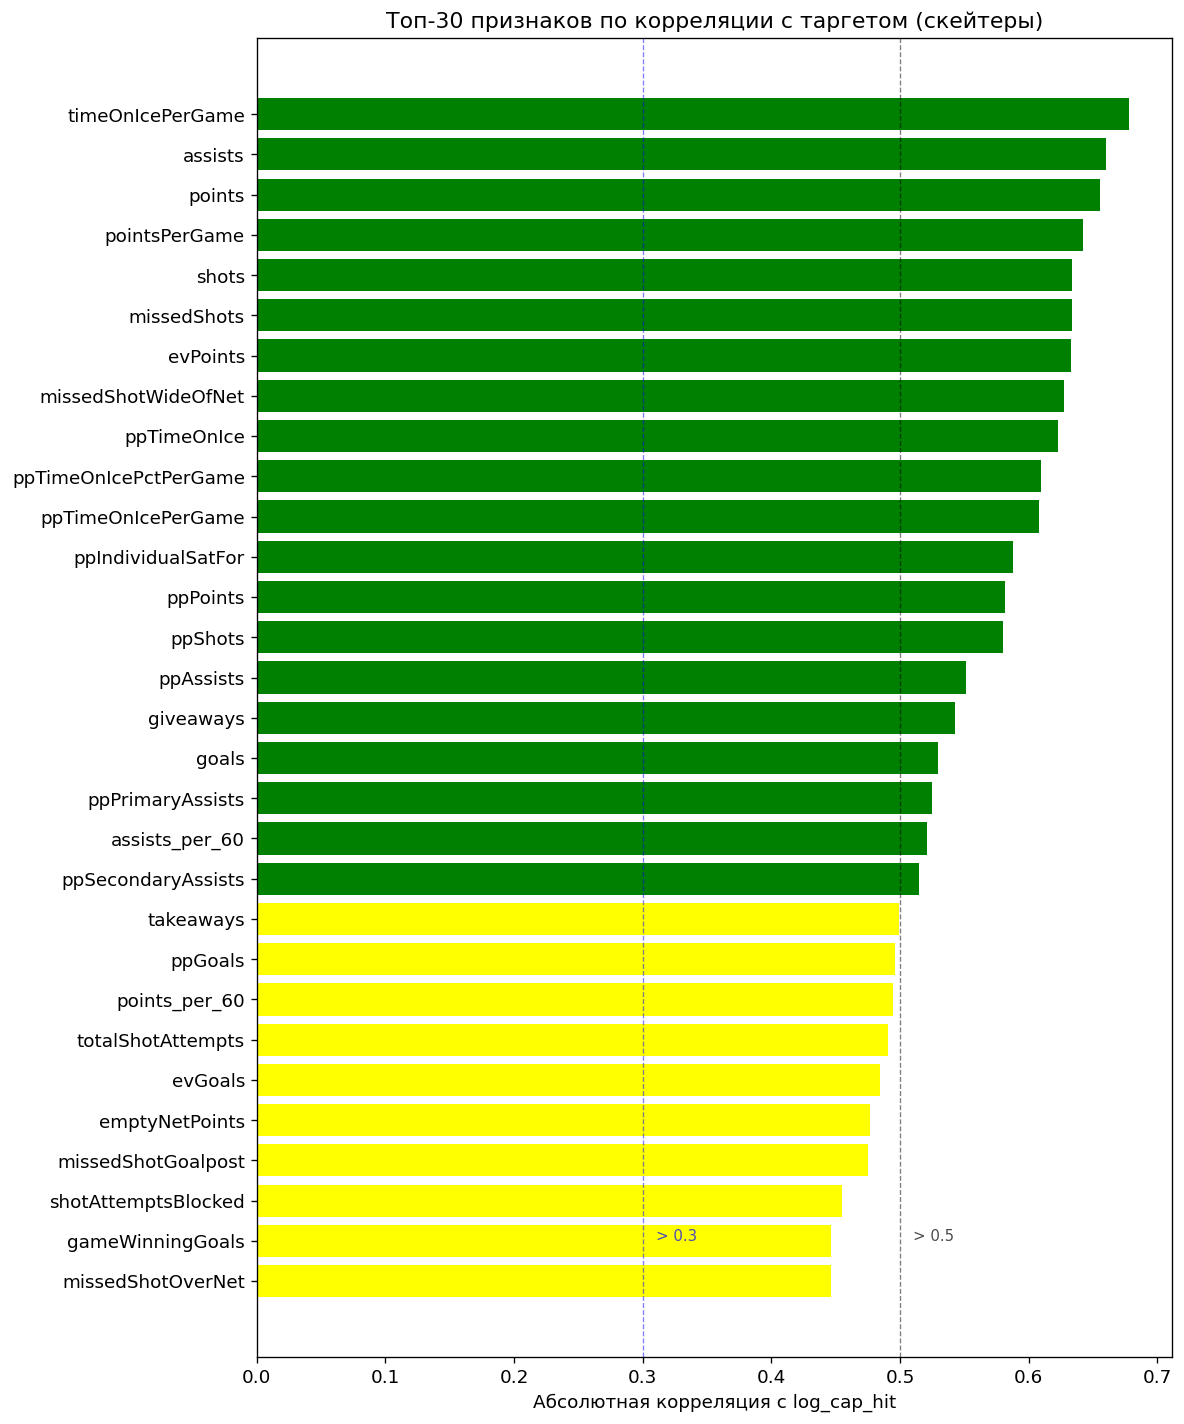

In [26]:
fig, ax = plt.subplots(figsize=(10, 12))

top30 = corr_with_target.head(30)
colors = ["green" if v > 0.5 else "yellow" if v > 0.3 else "red"
          for v in top30.values]

ax.barh(top30.index[::-1], top30.values[::-1], color=colors[::-1])
ax.set_xlabel("Абсолютная корреляция с log_cap_hit")
ax.set_title("Топ-30 признаков по корреляции с таргетом (скейтеры)")
ax.axvline(0.5, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0.3, color="blue", linewidth=0.8, linestyle="--", alpha=0.5)
ax.text(0.51, 1, "> 0.5", fontsize=9, color="black", alpha=0.7)
ax.text(0.31, 1, "> 0.3", fontsize=9, color="blue", alpha=0.7)

plt.tight_layout()
plt.savefig(root / "report/images/feature_correlations.png", bbox_inches="tight")
plt.show()

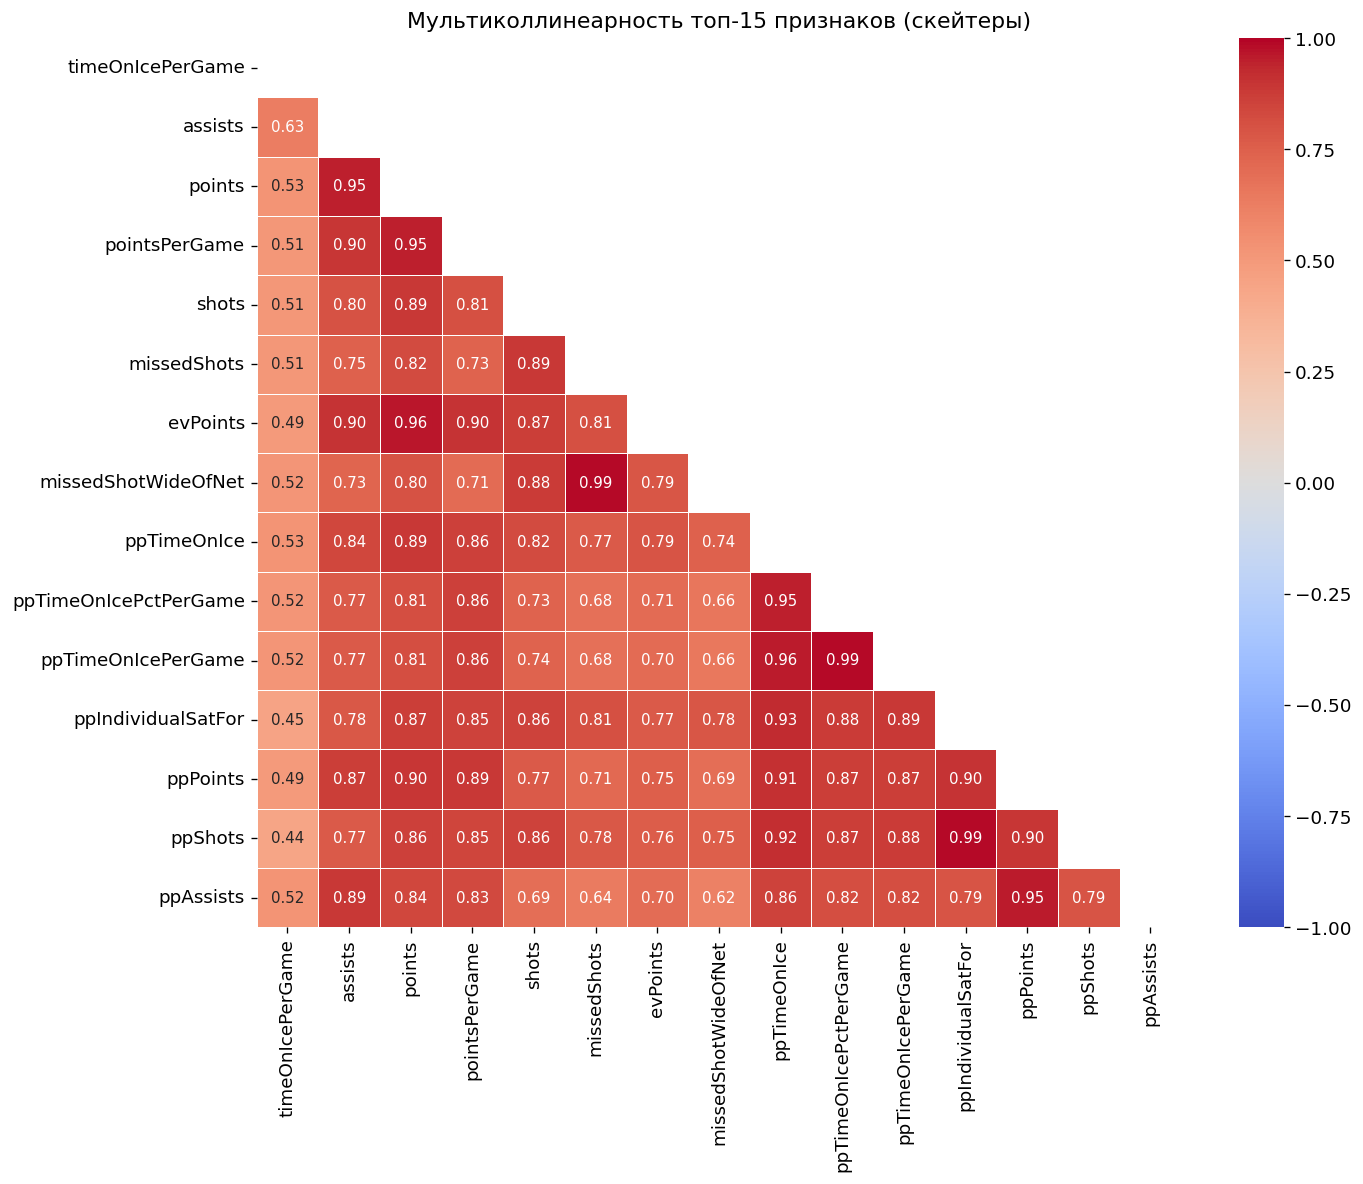

Пары с корреляцией > 0.85 (сильная мультиколлинеарность):
  ppTimeOnIcePctPerGame - ppTimeOnIcePerGame: 0.991
  ppIndividualSatFor - ppShots: 0.991
  missedShots - missedShotWideOfNet: 0.99
  points - evPoints: 0.964
  ppTimeOnIce - ppTimeOnIcePerGame: 0.961
  ppTimeOnIce - ppTimeOnIcePctPerGame: 0.953
  ppPoints - ppAssists: 0.953
  points - pointsPerGame: 0.951
  assists - points: 0.948
  ppTimeOnIce - ppIndividualSatFor: 0.925
  ppTimeOnIce - ppShots: 0.918
  ppTimeOnIce - ppPoints: 0.913
  assists - evPoints: 0.902
  ppIndividualSatFor - ppPoints: 0.9
  pointsPerGame - evPoints: 0.899
  points - ppPoints: 0.898
  ppPoints - ppShots: 0.898
  assists - pointsPerGame: 0.896
  shots - missedShots: 0.89
  points - shots: 0.887
  ppTimeOnIcePerGame - ppIndividualSatFor: 0.887
  assists - ppAssists: 0.886
  points - ppTimeOnIce: 0.886
  pointsPerGame - ppPoints: 0.886
  ppTimeOnIcePerGame - ppShots: 0.88
  shots - missedShotWideOfNet: 0.878
  ppTimeOnIcePctPerGame - ppIndividualSatFor: 0.

In [27]:
top15_features = corr_with_target.head(15).index.tolist()
corr_matrix = numeric_sk[top15_features].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"size": 9},
    linewidths=0.5,
)

ax.set_title("Мультиколлинеарность топ-15 признаков (скейтеры)")
plt.tight_layout()
plt.savefig(root / "report/images/multicollinearity_heatmap.png", bbox_inches="tight")
plt.show()

print("Пары с корреляцией > 0.85 (сильная мультиколлинеарность):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.85:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

for pair in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {pair[0]} - {pair[1]}: {pair[2]}")

### Мультиколлинеарность топ-15 признаков

Обнаружена 41 пара с корреляцией > 0.85, это очень высокий уровень
мультиколлинеарности. Выделяются три группы почти дублирующих признаков:

**Группа 1: очки и их производные:**
`points`, `assists`, `pointsPerGame`, `evPoints`, `ppPoints`, `ppAssists`
Все меряют одно и то же: результативность игрока. Из группы достаточно оставить
`points` и `pointsPerGame`.

**Группа 2: время в большинстве:**
`ppTimeOnIce`, `ppTimeOnIcePerGame`, `ppTimeOnIcePctPerGame`
Фактически одна и та же информация.
Оставляем `ppTimeOnIcePerGame`.

**Группа 3: броски и промахи:**
`shots`, `missedShots`, `missedShotWideOfNet`, `ppShots`, `ppIndividualSatFor`.
`missedShots` и `missedShotWideOfNet` коррелируют на 0.99 это почти дубли.
`ppIndividualSatFor` и `ppShots` тоже 0.99.

**Вывод:** датасет скейтеров содержит много избыточных признаков.
Это обосновывает применение методов уменьшения размерности на этапе моделирования:
- удаление дублирующих колонок вручную (на основе этого анализа)
- PCA или SelectFromModel для автоматического отбора

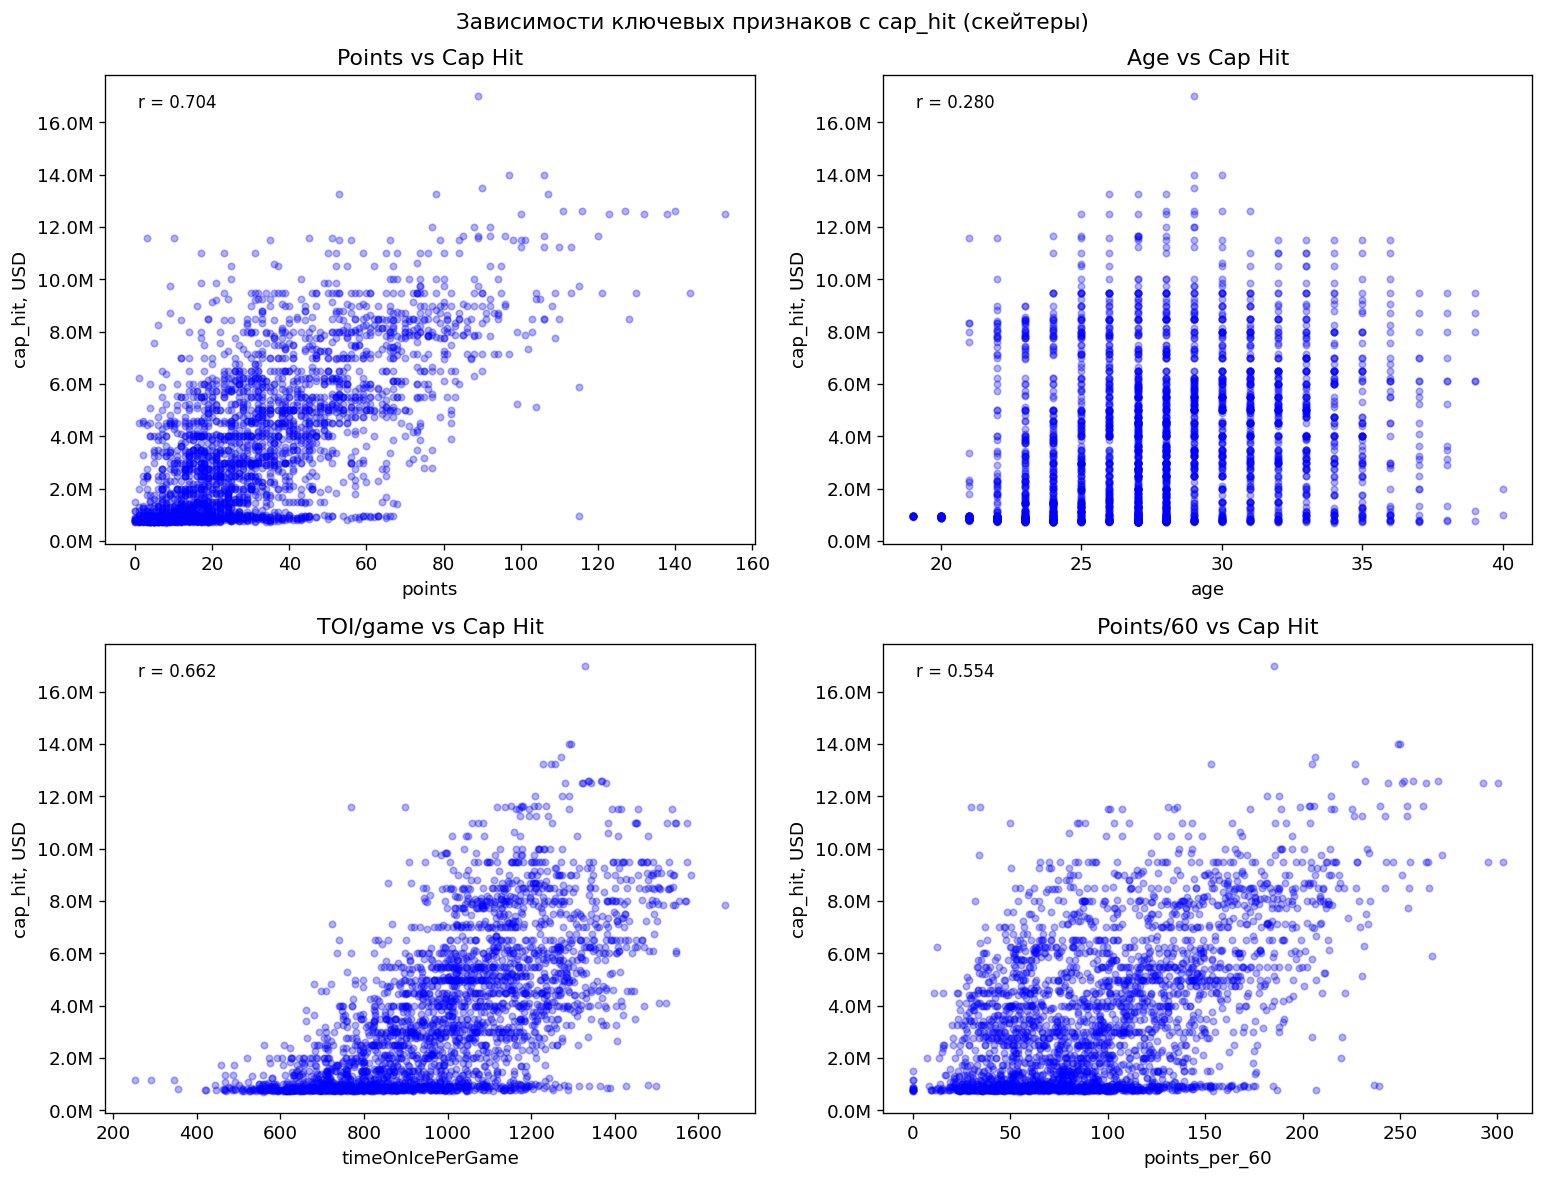

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

plots = [
    ("points", "cap_hit", "Points vs Cap Hit"),
    ("age", "cap_hit", "Age vs Cap Hit"),
    ("timeOnIcePerGame", "cap_hit", "TOI/game vs Cap Hit"),
    ("points_per_60", "cap_hit", "Points/60 vs Cap Hit"),
]

for ax, (x_col, y_col, title) in zip(axes.flatten(), plots):
    ax.scatter(
        sk[x_col], sk[y_col],
        alpha=0.3, s=15, color="blue"
    )
    ax.set_xlabel(x_col)
    ax.set_ylabel("cap_hit, USD")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

    corr = sk[[x_col, y_col]].corr().iloc[0, 1]
    ax.text(0.05, 0.93, f"r = {corr:.3f}", transform=ax.transAxes, fontsize=10)

plt.suptitle("Зависимости ключевых признаков с cap_hit (скейтеры)", fontsize=13)
plt.tight_layout()
plt.savefig(root / "report/images/scatter_plots.png", bbox_inches="tight")
plt.show()

### Scatter plots: ключевые зависимости

**Points vs Cap Hit** - самая сильная линейная зависимость.
Связь чёткая, но с большим разбросом в нижней части: много игроков с 0–20 очками
получают очень разные зарплаты. Это контракты подписанные авансом (молодые
перспективные игроки) или уже по инерции (ветераны на спаде).

**Age vs Cap Hit** — слабая линейная корреляция, но график
показывает нелинейность: зарплаты растут до +- 28–30 лет, потом разброс
сохраняется но медиана не падает резко. Видим дискретность. Линейная модель эту нелинейность не поймает,
но деревья поймают.

**TOI/game vs Cap Hit** — сильная зависимость. Игроки с > 1200 сек/игру почти всегда получают > 4M.

**Points/60 vs Cap Hit** — умеренная связь. Признак полезен, но требует аккуратного обращения с выбросами.

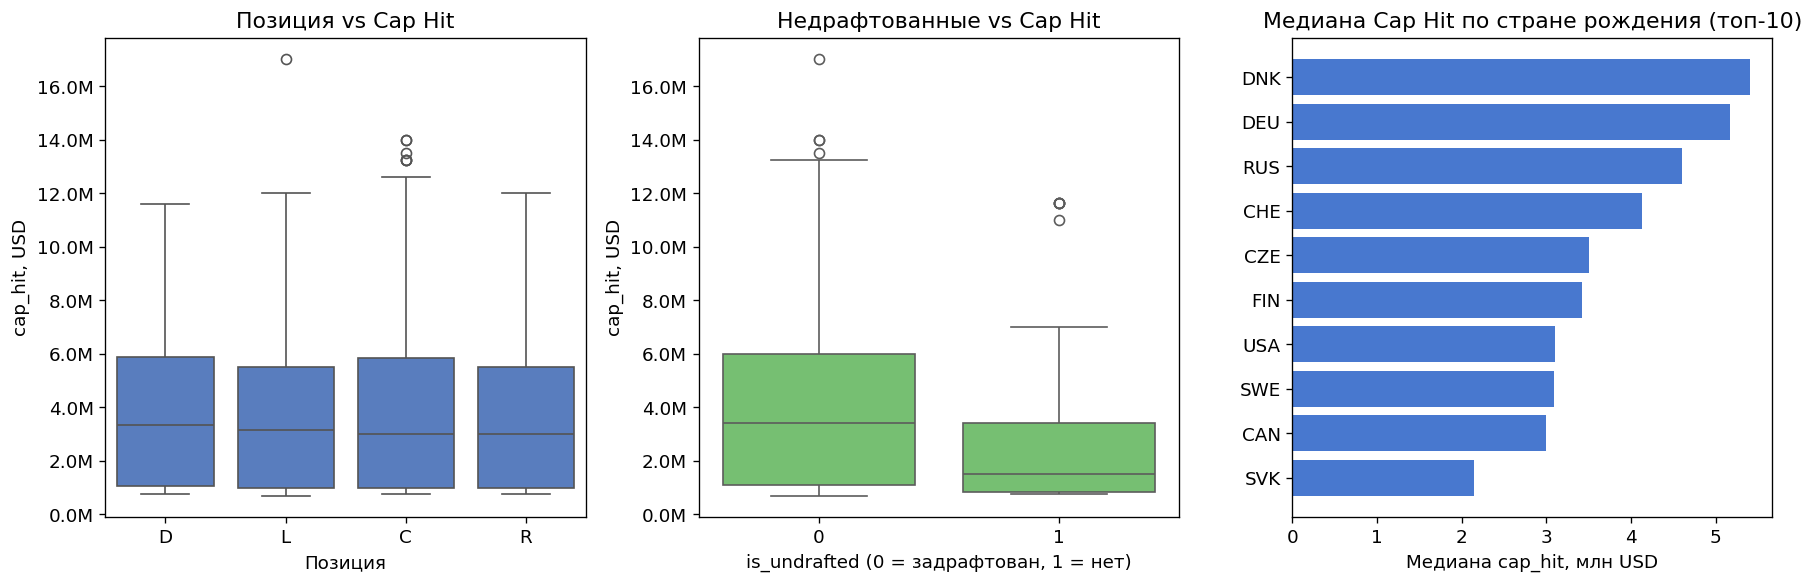

Медианные зарплаты по позициям:
positionCode
D    3.33M
L    3.15M
C    3.00M
R    3.00M

Медиана зарплаты задрафтованных vs недрафтованных:
is_undrafted
0    3.40M
1    1.50M

Топ-10 стран по количеству игроков и медиане зарплаты:
              count median
birthCountry              
CAN            1217  3.00M
USA             861  3.10M
SWE             292  3.09M
RUS             160  4.60M
FIN             138  3.42M
CZE              75  3.50M
CHE              45  4.12M
SVK              26  2.15M
DEU              24  5.17M
DNK              15  5.40M


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# positionCode vs cap_hit
pos_order = sk.groupby("positionCode")["cap_hit"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=sk, x="positionCode", y="cap_hit", order=pos_order,
            ax=axes[0], color="#4878CF")
axes[0].set_title("Позиция vs Cap Hit")
axes[0].set_xlabel("Позиция")
axes[0].set_ylabel("cap_hit, USD")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# is_undrafted vs cap_hit
sns.boxplot(data=sk, x="is_undrafted", y="cap_hit", ax=axes[1], color="#6ACC65")
axes[1].set_title("Недрафтованные vs Cap Hit")
axes[1].set_xlabel("is_undrafted (0 = задрафтован, 1 = нет)")
axes[1].set_ylabel("cap_hit, USD")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# топ-10 стран
top_countries = sk["birthCountry"].value_counts().head(10).index
country_medians = (
    sk[sk["birthCountry"].isin(top_countries)]
    .groupby("birthCountry")["cap_hit"]
    .median()
    .sort_values(ascending=False)
)
axes[2].barh(country_medians.index[::-1], country_medians.values[::-1] / 1e6,
             color="#4878CF")
axes[2].set_title("Медиана Cap Hit по стране рождения (топ-10)")
axes[2].set_xlabel("Медиана cap_hit, млн USD")

plt.tight_layout()
plt.savefig(root / "report/images/categorical_vs_target.png", bbox_inches="tight")
plt.show()

print("Медианные зарплаты по позициям:")
print(sk.groupby("positionCode")["cap_hit"].median().sort_values(ascending=False)
      .apply(lambda x: f"{x/1e6:.2f}M").to_string())
print()
print("Медиана зарплаты задрафтованных vs недрафтованных:")
print(sk.groupby("is_undrafted")["cap_hit"].median()
      .apply(lambda x: f"{x/1e6:.2f}M").to_string())
print()
print("Топ-10 стран по количеству игроков и медиане зарплаты:")
country_stats = (
    sk[sk["birthCountry"].isin(top_countries)]
    .groupby("birthCountry")["cap_hit"]
    .agg(["count", "median"])
    .sort_values("count", ascending=False)
)
country_stats["median"] = country_stats["median"].apply(lambda x: f"{x/1e6:.2f}M")
print(country_stats.to_string())

### Категориальные признаки vs Cap Hit

**Позиция:**
Защитники получают чуть больше (медиана 3.33M против 3.00M у центров и правых).
Разница небольшая т.к. позиция сама по себе слабый предиктор,
но в комбинации с другими признаками может быть полезна для деревьев.

**Задрафтованные vs недрафтованные:**
Очень чёткая разница: медиана 3.40M против 1.50M. Недрафтованные игроки
в среднем получают вдвое меньше. Признак `is_undrafted` информативен несмотря
на невысокую линейную корреляцию.

**Страна рождения:**
Интересная картина: топ по медиане зарплаты занимают не самые многочисленные страны:
- DNK и DEU: малая выборка, результат нестабилен
- RUS: стабильный результат, российские игроки в NHL в среднем звёздного уровня 
- SVK: самая низкая медиана среди топ-10 стран
- CAN и USA: самые многочисленные, медианы близки к общей

Страна рождения как признак требует осторожности из-за малых выборок по ряду стран.

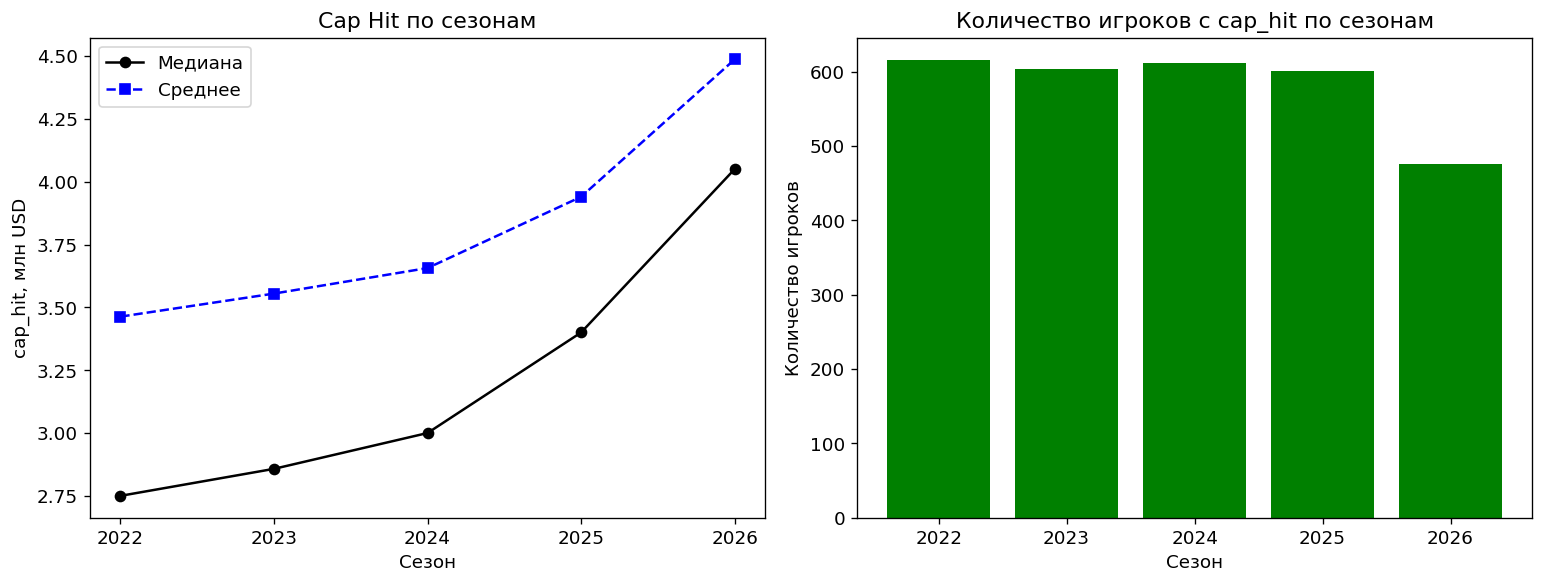

Статистика cap_hit по сезонам:
            медиана среднее  количество
season_year                            
2022          2.75M   3.46M         615
2023          2.86M   3.55M         603
2024          3.00M   3.66M         611
2025          3.40M   3.94M         601
2026          4.05M   4.49M         476


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

season_stats = sk.groupby("season_year")["cap_hit"].agg(["median", "mean", "count"])
season_stats.columns = ["медиана", "среднее", "количество"]

axes[0].plot(season_stats.index, season_stats["медиана"] / 1e6,
             marker="o", color="black", label="Медиана")
axes[0].plot(season_stats.index, season_stats["среднее"] / 1e6,
             marker="s", color="blue", linestyle="--", label="Среднее")
axes[0].set_title("Cap Hit по сезонам")
axes[0].set_xlabel("Сезон")
axes[0].set_ylabel("cap_hit, млн USD")
axes[0].legend()
axes[0].set_xticks(season_stats.index)

axes[1].bar(season_stats.index, season_stats["количество"], color="green")
axes[1].set_title("Количество игроков с cap_hit по сезонам")
axes[1].set_xlabel("Сезон")
axes[1].set_ylabel("Количество игроков")
axes[1].set_xticks(season_stats.index)

plt.tight_layout()
plt.savefig(root / "report/images/salary_by_season.png", bbox_inches="tight")
plt.show()

print("Статистика cap_hit по сезонам:")
season_stats["медиана"] = season_stats["медиана"].apply(lambda x: f"{x/1e6:.2f}M")
season_stats["среднее"] = season_stats["среднее"].apply(lambda x: f"{x/1e6:.2f}M")
print(season_stats.to_string())

### Анализ по сезонам

Чёткий тренд роста зарплат: медиана выросла с 2.75M в 2022 до 4.05M в 2026. Среднее растёт чуть быстрее медианы, что говорит
о росте топ-контрактов опережающим темпом.

Это объясняется ростом потолка зарплат NHL (salary cap) каждый год: все контракты
индексируются относительно потолка, поэтому абсолютные значения растут даже
если реальная ценность игрока не изменилась.

**Важное следствие для модели:**
`season_year` должен войти в список признаков, без него модель обученная на 2022–2024
будет систематически занижать предсказания для 2025–2026.
Также стоит рассмотреть нормализацию `cap_hit` относительно потолка сезона, это уберёт инфляционный тренд и сделает
признаки более сопоставимыми между сезонами.

Количество игроков стабильно (~600) кроме 2026 (476) т.к. сезон собирался
до его завершения, поэтому часть контрактов отсутствует на Spotrac.

## Вратари

Выборка значительно меньше т.е.
выводы будут менее статистически устойчивы, но структура данных принципиально другая,
поэтому вратари рассматриваются отдельно.

In [33]:
id_cols_go = ["playerId", "goalieFullName", "lastName", "season", "seasonId",
              "teamAbbrevs", "shootsCatches", "birthCity", "birthCountry"]
drop_cols_go = id_cols_go + ["cap_hit", "season_year"]

numeric_go = go.drop(columns=[c for c in drop_cols_go if c in go.columns], errors="ignore")
numeric_go = numeric_go.select_dtypes(include=[np.number])

corr_go = (
    numeric_go.corr()["log_cap_hit"]
    .drop("log_cap_hit")
    .abs()
    .sort_values(ascending=False)
)

print("Все признаки вратарей по корреляции с log_cap_hit:")
print(corr_go.round(3).to_string())

Все признаки вратарей по корреляции с log_cap_hit:
gamesStarted           0.680
completeGames          0.675
timeOnIce              0.663
gamesPlayed            0.653
goalsFor               0.642
qualityStart           0.632
shotsAgainst           0.631
saves                  0.630
wins                   0.611
regulationWins         0.602
goalsAgainst           0.599
starter_ratio          0.558
regulationLosses       0.503
losses                 0.473
shutouts               0.403
otLosses               0.365
gsaa_proxy             0.350
incompleteGames        0.334
points                 0.311
assists                0.303
penaltyMinutes         0.287
win_rate               0.282
is_undrafted           0.250
draftYear              0.249
draft_value            0.245
goalsAgainstAverage    0.224
qualityStartsPct       0.188
age                    0.182
savePct                0.155
shotsAgainstPer60      0.152
draftOverall           0.137
draftRound             0.098
is_multi_team        

### Корреляция признаков вратарей с log_cap_hit

Картина принципиально отличается от скейтеров:
- `gamesStarted`, `gamesPlayed`, `timeOnIce` т.е.
  количество игр сильнее всего предсказывает зарплату
- `wins`, `saves`, `shotsAgainst` абсолютные показатели,
  тоже зависят от количества игр

**Качественные метрики**
- `savePct` почти не коррелирует с зарплатой линейно
- `goalsAgainstAverage` тоже слабо
- `gsaa_proxy` :наш расчётный признак работает лучше сырых метрик качества
- `qualityStartsPct` слабая корреляция

**Вывод:** GM платят вратарям прежде всего за надёжность и игры.
Качественные метрики важны, но зарплата во многом определяется статусом, который отражает `starter_ratio`.

**Почти бесполезные признаки:**
`size_index`, `completeGamePct`, `goalsForAverage`,
`weightInPounds`, их можно смело убирать.

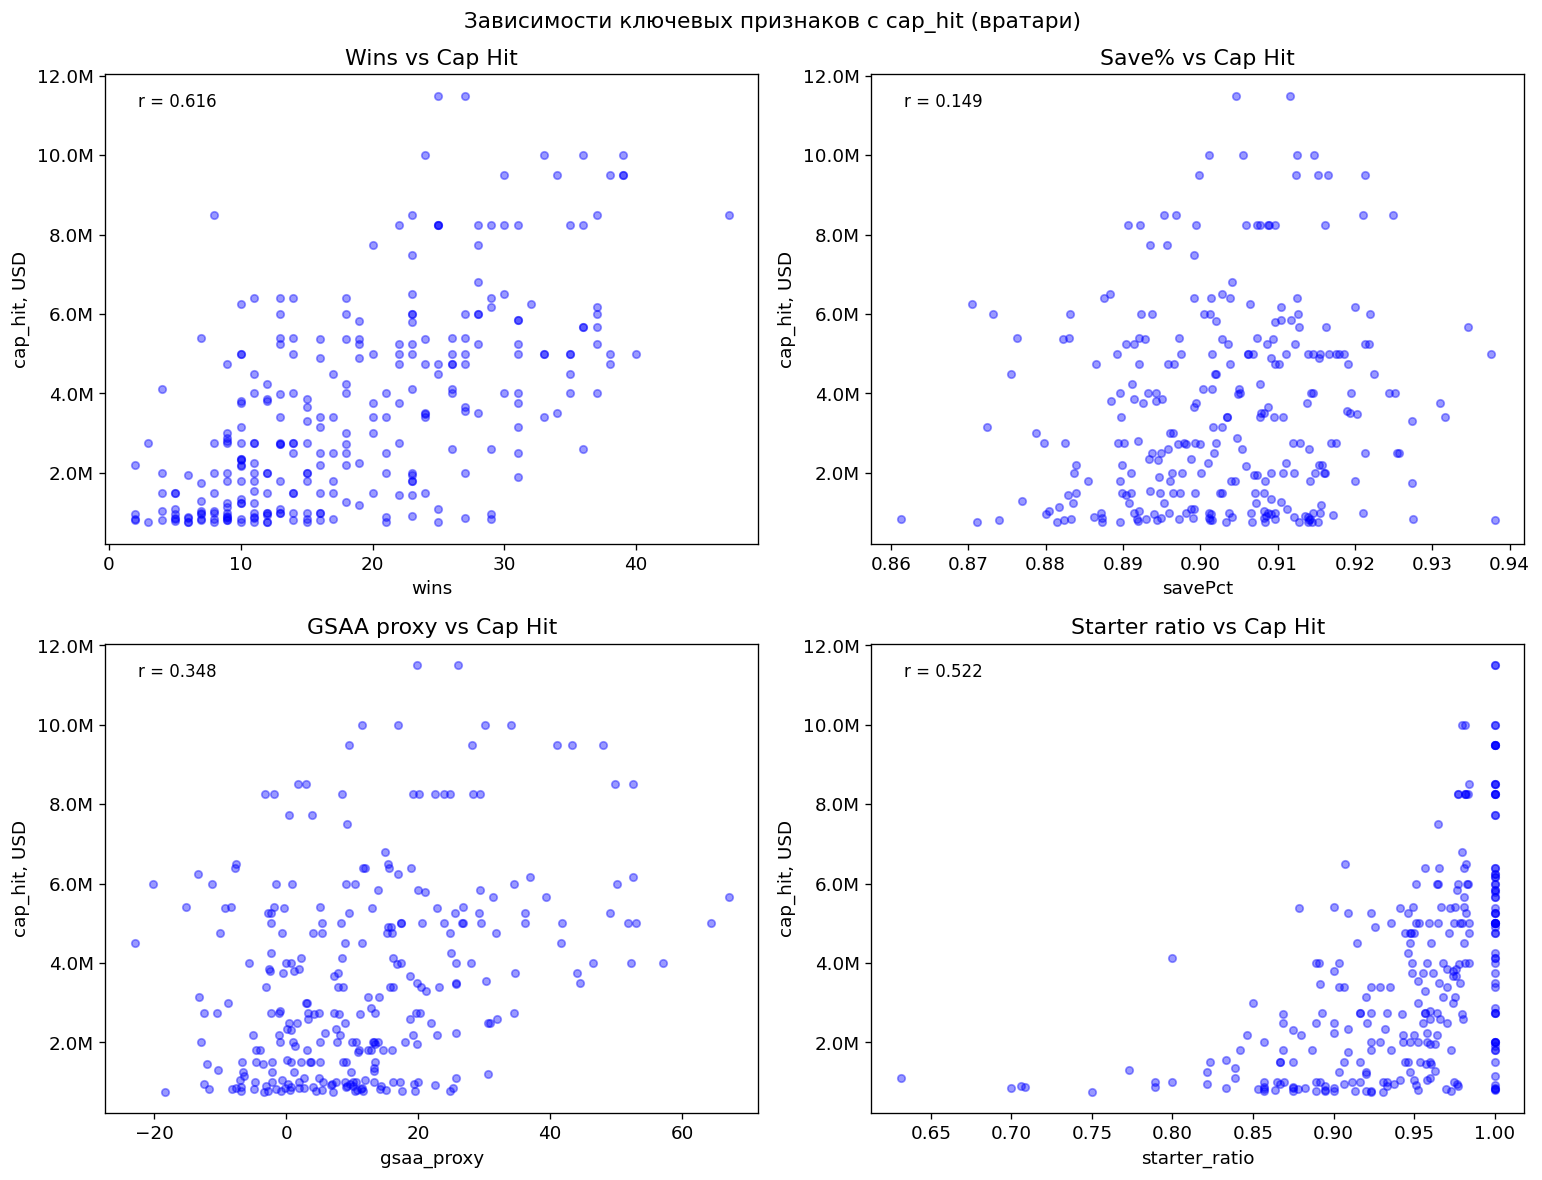

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

plots_go = [
    ("wins", "cap_hit", "Wins vs Cap Hit"),
    ("savePct", "cap_hit", "Save% vs Cap Hit"),
    ("gsaa_proxy", "cap_hit", "GSAA proxy vs Cap Hit"),
    ("starter_ratio", "cap_hit", "Starter ratio vs Cap Hit"),
]

for ax, (x_col, y_col, title) in zip(axes.flatten(), plots_go):
    ax.scatter(go[x_col], go[y_col], alpha=0.4, s=20, color="blue")
    ax.set_xlabel(x_col)
    ax.set_ylabel("cap_hit, USD")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    corr = go[[x_col, y_col]].corr().iloc[0, 1]
    ax.text(0.05, 0.93, f"r = {corr:.3f}", transform=ax.transAxes, fontsize=10)

plt.suptitle("Зависимости ключевых признаков с cap_hit (вратари)", fontsize=13)
plt.tight_layout()
plt.savefig(root / "report/images/goalie_scatter_plots.png", bbox_inches="tight")
plt.show()

### Scatter plots для вратарей

**Wins vs Cap Hit**: сильная связь, но это во многом отражает
количество игр. Разброс большой.

**Save% vs Cap Hit**: почти нет линейной связи.
График подтверждает: диапазон savePct у всех вратарей узкий,
и внутри этого диапазона зарплата определяется не качеством, а репутацией.

**GSAA proxy vs Cap Hit**: умеренная связь, лучше чем savePct.
Есть выбросы влево с высокой
зарплатой. Признак полезен, но не доминирует.

**Starter ratio vs Cap Hit**: хорошая связь.
Чёткое разделение: вратари с `starter_ratio` < 0.8 почти все получают < 3M,
выше 0.95 уже идёт широкий разброс от 1M до 12M. Статус стартера необходим,
но не достаточен для высокой зарплаты.

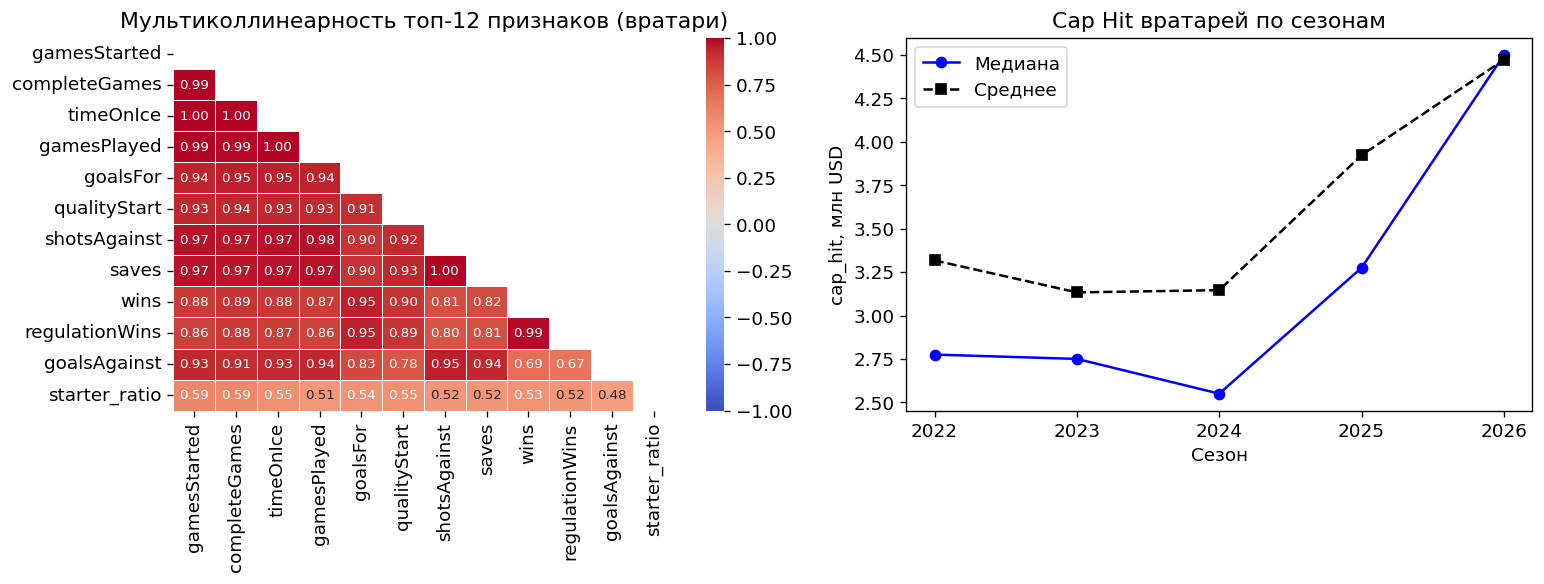

Пары вратарей с корреляцией > 0.85:
  shotsAgainst — saves: 0.999
  gamesStarted — timeOnIce: 0.997
  timeOnIce — gamesPlayed: 0.997
  completeGames — timeOnIce: 0.996
  gamesStarted — gamesPlayed: 0.995
  gamesStarted — completeGames: 0.994
  wins — regulationWins: 0.992
  completeGames — gamesPlayed: 0.988
  gamesPlayed — shotsAgainst: 0.975
  timeOnIce — shotsAgainst: 0.974
  gamesStarted — shotsAgainst: 0.973
  timeOnIce — saves: 0.973
  gamesPlayed — saves: 0.973
  gamesStarted — saves: 0.971
  completeGames — shotsAgainst: 0.966
  completeGames — saves: 0.965
  goalsFor — wins: 0.952
  completeGames — goalsFor: 0.951
  timeOnIce — goalsFor: 0.95
  shotsAgainst — goalsAgainst: 0.947
  goalsFor — regulationWins: 0.946
  gamesStarted — goalsFor: 0.945
  gamesPlayed — goalsFor: 0.941
  gamesPlayed — goalsAgainst: 0.937
  saves — goalsAgainst: 0.936
  completeGames — qualityStart: 0.935
  timeOnIce — qualityStart: 0.935
  gamesStarted — qualityStart: 0.933
  qualityStart — saves: 0.93

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# мультиколлинеарность вратарей
top12_go = corr_go.head(12).index.tolist()
corr_matrix_go = numeric_go[top12_go].corr()

mask = np.triu(np.ones_like(corr_matrix_go, dtype=bool))
sns.heatmap(
    corr_matrix_go,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0],
    annot_kws={"size": 8},
    linewidths=0.5,
)
axes[0].set_title("Мультиколлинеарность топ-12 признаков (вратари)")

# по сезонам
season_go = go.groupby("season_year")["cap_hit"].agg(["median", "mean", "count"])
axes[1].plot(season_go.index, season_go["median"] / 1e6,
             marker="o", color="blue", label="Медиана")
axes[1].plot(season_go.index, season_go["mean"] / 1e6,
             marker="s", color="black", linestyle="--", label="Среднее")
axes[1].set_title("Cap Hit вратарей по сезонам")
axes[1].set_xlabel("Сезон")
axes[1].set_ylabel("cap_hit, млн USD")
axes[1].legend()
axes[1].set_xticks(season_go.index)

plt.tight_layout()
plt.savefig(root / "report/images/goalie_multicollinearity_seasons.png", bbox_inches="tight")
plt.show()

print("Пары вратарей с корреляцией > 0.85:")
high_corr_go = []
for i in range(len(corr_matrix_go.columns)):
    for j in range(i + 1, len(corr_matrix_go.columns)):
        val = corr_matrix_go.iloc[i, j]
        if abs(val) > 0.85:
            high_corr_go.append((corr_matrix_go.columns[i], corr_matrix_go.columns[j], round(val, 3)))
for pair in sorted(high_corr_go, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {pair[0]} — {pair[1]}: {pair[2]}")

print()
print("Cap Hit вратарей по сезонам:")
season_go["median"] = season_go["median"].apply(lambda x: f"{x/1e6:.2f}M")
season_go["mean"] = season_go["mean"].apply(lambda x: f"{x/1e6:.2f}M")
print(season_go.to_string())

### Мультиколлинеарность и сезоны для вратарей

**Мультиколлинеарность критическая**: 47 пар с корреляцией > 0.85 т.к.
всё сводится к одному фактору: количество сыгранных игр.

`gamesStarted`, `gamesPlayed`, `timeOnIce`, `completeGames` коррелируют
на 0.99–1.00 между собой, это буквально почти одна и та же информация в разных единицах.
`shotsAgainst` и `saves` тоже коррелируют на 0.999 т.к. очевидно что больше бросков = больше сейвов.
`wins` и `regulationWins` 0.992 тоже высокая.

**Вывод по признакам вратарей:**
Из группы объёма достаточно оставить один признак — `gamesStarted` как наиболее
прямой показатель статуса вратаря.

Из пары `shotsAgainst`/`saves` оставляем `shotsAgainst`.

Из пары `wins`/`regulationWins` оставляем `wins` как более общий показатель.

Качественные метрики (`savePct`, `gsaa_proxy`, `qualityStartsPct`) слабо
коррелируют между собой и с объёмными признаками, оставляем все три.

**Сезоны вратарей:**
Интересный провал медианы в 2024, возможно в этом сезоне на Spotrac
попало больше бэкап-вратарей. Резкий рост в 2025–2026 совпадает с трендом
скейтеров.

## Сплит данных

Данные разбиты по сезонам в хронологическом порядке:

| Сплит | Сезоны | Скейтеры | Вратари |
|---|---|---|---|
| Train | 2022, 2023, 2024 | 1829 | 175 |
| Val | 2025 | 601 | 60 |
| Test | 2026 | 476 | 51 |

**Почему такой split, а не случайный:**
Cap hit назначается до начала сезона на основе статистики прошлых лет.
Случайный split создаёт утечку данных: модель видит игроков из будущих
сезонов при обучении и учится предсказывать не совсем правильно.
А наш split имитирует реальное использование модели: обучаемся на прошлом,
предсказываем будущее.

**Ненужные удалены до разбивки:**
`player_name_cw`, `team_cw`, `position_cw`, `name_key` которые пришли из Spotrac
вместе с таргетом и не могут использоваться как признаки мы удалили.

**Замечание по вратарям:**
Test-выборка вратарей (51 игрок) мала для надёжной оценки.
На этапе моделирования для вратарей будем использовать
кросс-валидацию по сезонам вместо единственного test-сплита.

## Выбор метрик качества

Задача: регрессия на `log_cap_hit` с последующим переводом через `expm1`.
Оцениваем метрики в исходном пространстве (USD).

**Приоритет: MAE**
- Интерпретируема напрямую: "модель ошибается в среднем на X долларов"
- Для зарплат важнее средняя ошибка, а не штраф за единичные промахи

**RMSE как вторая метрика**: следим чтобы не было больших ошибок
на топ-контрактах.

**R² для сравнения моделей** между собой и с baseline.

## Выводы второй части EDA

### Информативные признаки
Топ по корреляции с log_cap_hit:
1. `timeOnIcePerGame` (0.678)
2. `assists` (0.660) 
3. `points` (0.655) 
4. `pointsPerGame` (0.642)
5. `shots` (0.634), `missedShots` (0.633), `evPoints` (0.633)

### Кандидаты на сокращение

Сокращение признаков актуально прежде всего для линейных моделей.

- Время в большинстве: `ppTimeOnIce`, `ppTimeOnIcePerGame`, `ppTimeOnIcePctPerGame`
  коррелируют на 0.95–0.99, достаточно одного (`ppTimeOnIcePerGame`)
- Промахи: `missedShotWideOfNet` и `missedShots` корреляция 0.99,
  убираем `missedShotWideOfNet`
- `ppIndividualSatFor` и `ppShots` корреляция 0.99, убираем один из двух.
- Группа очков (`points`, `assists`, `evPoints`, `ppPoints`): высокая
  взаимная корреляция, но каждый признак несёт информацию о разной игровой
  ситуации. Не убираем вручную.

### Гипотезы для моделирования
1. Нелинейные модели возможно превзойдут линейные, мультиколлинеарность мешает линейным
2. `timeOnIcePerGame` и `points` войдут в топ важности признаков у деревьев
3. Нормализация cap_hit на потолок сезона может улучшить качество т.к.
   инфляция контрактов создаёт систематический сдвиг между сезонами
4. Для вратарей `gsaa_proxy` и `starter_ratio` будут ключевыми признаками
5. Уменьшение размерности улучшит линейные модели